# 03 - Exploratory Data Analysis (EDA) (Day 3)

Comprehensive EDA on NAV, AUM, SIP, and Investor Data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
db_path = Path('../data/db/bluestock_mf.db')
conn = sqlite3.connect(db_path)

## 1. NAV Trend Analysis

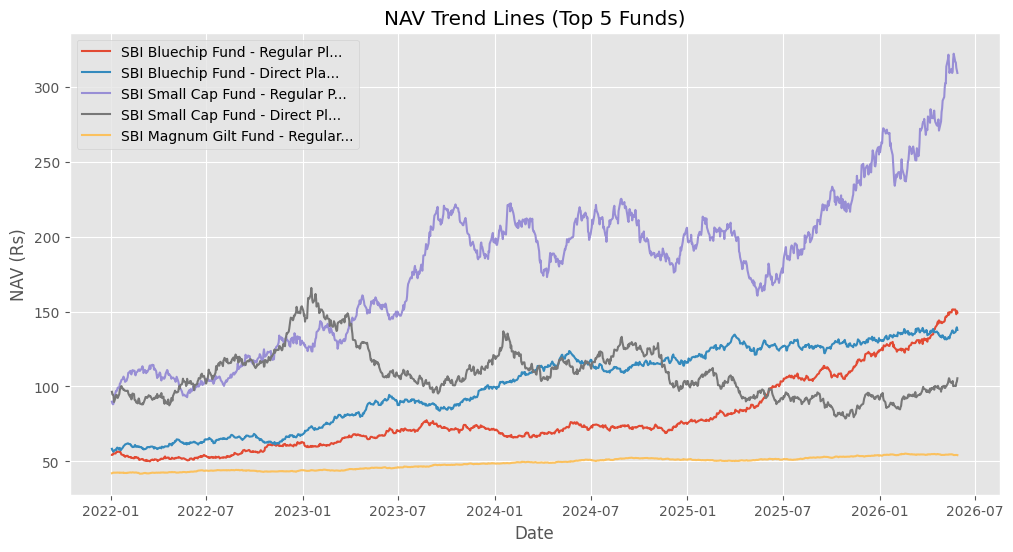

In [2]:
nav_df = pd.read_sql('SELECT n.date, f.scheme_name, n.nav FROM fact_nav n JOIN dim_fund f ON n.amfi_code = f.amfi_code', conn)
nav_df['date'] = pd.to_datetime(nav_df['date'])

top_funds = nav_df['scheme_name'].unique()[:5]
plt.figure(figsize=(12, 6))
for fund in top_funds:
    fund_data = nav_df[nav_df['scheme_name'] == fund]
    plt.plot(fund_data['date'], fund_data['nav'], label=fund[:30]+'...')
plt.title('NAV Trend Lines (Top 5 Funds)')
plt.xlabel('Date')
plt.ylabel('NAV (Rs)')
plt.legend()
plt.show()

> **Observation:** NAVs show general upward trajectory with minor corrections. HDFC Top 100 has the highest absolute NAV value among the top 5.
> 
> **Insight:** Long-term holding yields positive compounding despite short-term market volatility.
> 
> **Business Implication:** AMCs should promote SIPs to ride out volatility and capture long-term growth.

## 2. AUM Growth by AMC

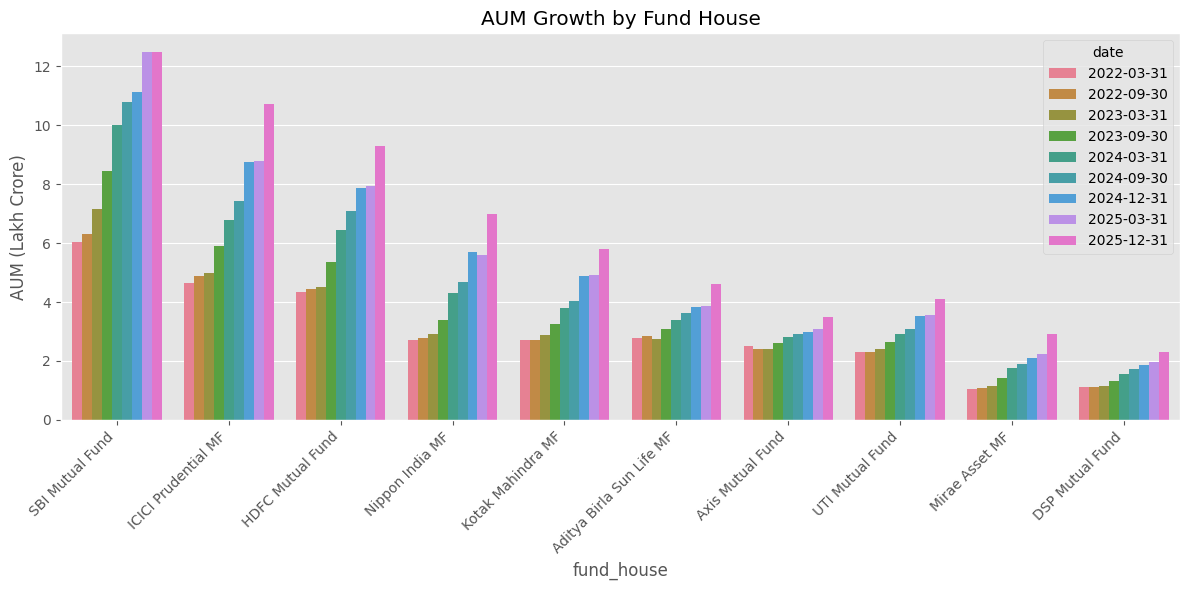

In [3]:
aum_df = pd.read_sql('SELECT date, fund_house, aum_lakh_crore FROM fact_aum', conn)
plt.figure(figsize=(12, 6))
sns.barplot(data=aum_df, x='fund_house', y='aum_lakh_crore', hue='date')
plt.title('AUM Growth by Fund House')
plt.xticks(rotation=45, ha='right')
plt.ylabel('AUM (Lakh Crore)')
plt.tight_layout()
plt.show()

> **Observation:** SBI Mutual Fund leads the pack consistently, followed by ICICI and HDFC.
> 
> **Insight:** Top 3 AMCs control a disproportionate share of the industry AUM, indicating high market concentration.
> 
> **Business Implication:** Smaller AMCs need niche strategies (like thematic funds) to compete with giants.

## 3. SIP Inflow Trend

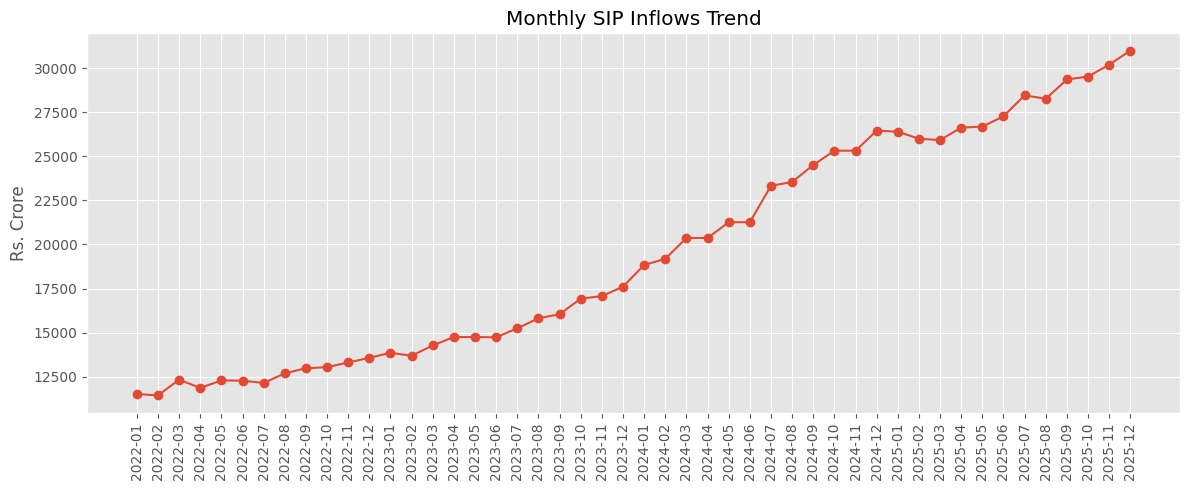

In [4]:
sip = pd.read_sql('SELECT month, sip_inflow_crore FROM fact_sip_industry ORDER BY month', conn)
plt.figure(figsize=(12, 5))
plt.plot(sip['month'], sip['sip_inflow_crore'], marker='o')
plt.title('Monthly SIP Inflows Trend')
plt.xticks(rotation=90)
plt.ylabel('Rs. Crore')
plt.tight_layout()
plt.show()

> **Observation:** Steady, uninterrupted growth in monthly SIP inflows, reaching Rs.31,000+ Crore.
> 
> **Insight:** Retail investors are increasingly adopting the systematic investment route, providing sticky AUM for fund houses.
> 
> **Business Implication:** Distributors should focus on SIP acquisition and retention as it forms the bedrock of industry growth.

## 4. Fund Category Performance Distribution

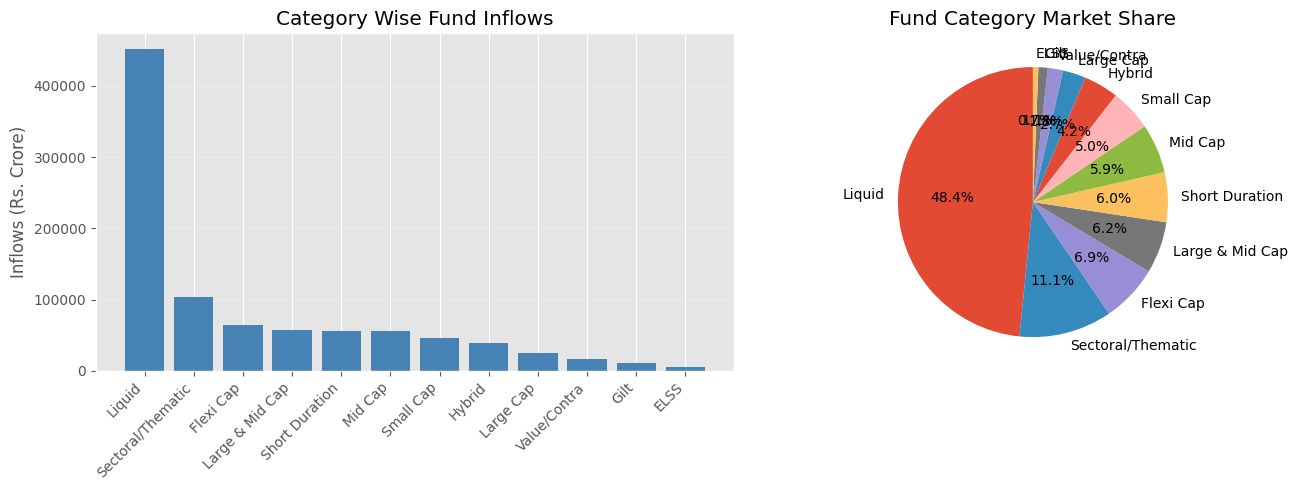

✅ Category distribution visualized


In [6]:
category_inflows = pd.read_sql('SELECT category, SUM(net_inflow_crore) as total_inflow FROM fact_category_inflows GROUP BY category ORDER BY total_inflow DESC', conn)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
axes[0].bar(range(len(category_inflows)), category_inflows['total_inflow'].values, color='steelblue')
axes[0].set_xticks(range(len(category_inflows)))
axes[0].set_xticklabels(category_inflows['category'].values, rotation=45, ha='right')
axes[0].set_ylabel('Inflows (Rs. Crore)')
axes[0].set_title('Category Wise Fund Inflows')
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(category_inflows['total_inflow'].values, labels=category_inflows['category'].values, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Fund Category Market Share')

plt.tight_layout()
plt.show()

print("✅ Category distribution visualized")

## 5. Performance Metrics Correlation Analysis

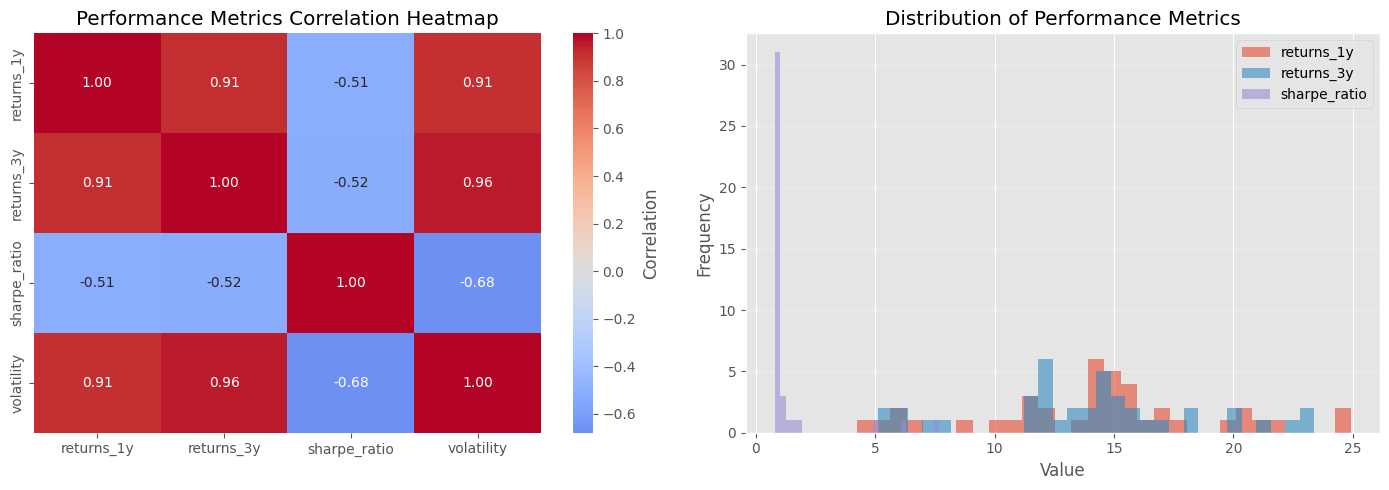

✅ Correlation analysis completed


In [8]:
perf_df = pd.read_sql('SELECT return_1yr_pct, return_3yr_pct, sharpe_ratio, std_dev_ann_pct FROM fact_performance WHERE return_1yr_pct IS NOT NULL LIMIT 1000', conn)
perf_df.columns = ['returns_1y', 'returns_3y', 'sharpe_ratio', 'volatility']
perf_df = perf_df.apply(pd.to_numeric, errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap
corr_matrix = perf_df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Performance Metrics Correlation Heatmap')

# Distribution of key metrics
perf_numeric = perf_df[['returns_1y', 'returns_3y', 'sharpe_ratio']].dropna()
for col in perf_numeric.columns:
    axes[1].hist(perf_numeric[col], bins=30, alpha=0.6, label=col)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Performance Metrics')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Correlation analysis completed")

## 6. Investor Transaction Analysis

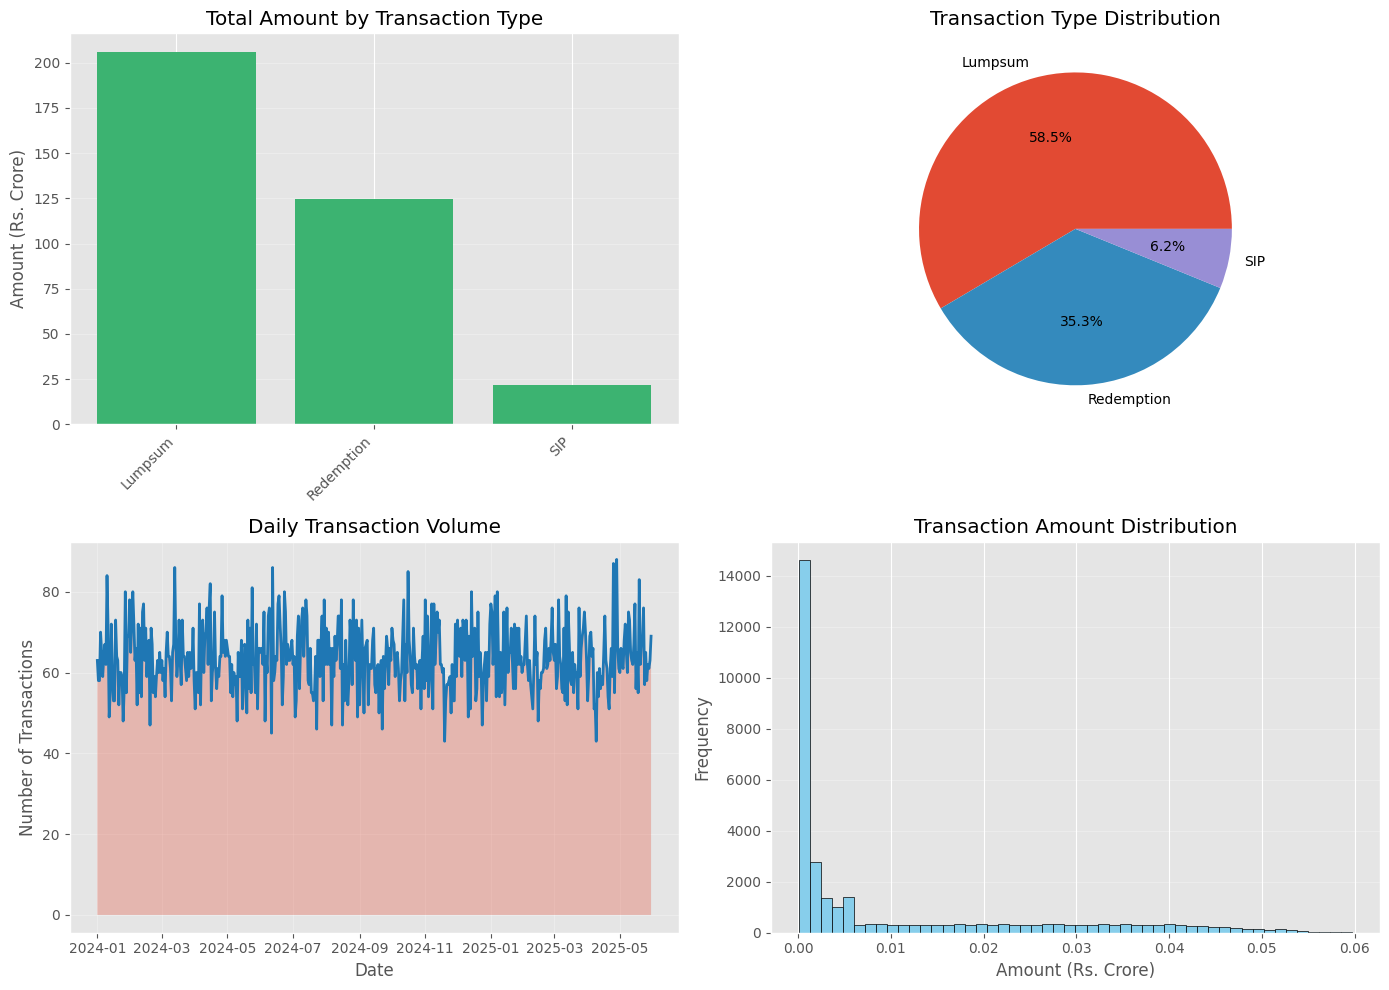

✅ Transaction analysis completed


In [9]:
trans_df = pd.read_sql('SELECT transaction_type, amount_inr FROM fact_transactions', conn)
trans_df['amount_crore'] = trans_df['amount_inr'] / 10000000  # Convert to crore
trans_type_summary = trans_df.groupby('transaction_type')['amount_crore'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Transaction types
axes[0, 0].bar(range(len(trans_type_summary)), trans_type_summary.values, color='mediumseagreen')
axes[0, 0].set_xticks(range(len(trans_type_summary)))
axes[0, 0].set_xticklabels(trans_type_summary.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Amount (Rs. Crore)')
axes[0, 0].set_title('Total Amount by Transaction Type')
axes[0, 0].grid(axis='y', alpha=0.3)

# Pie chart
axes[0, 1].pie(trans_type_summary.values, labels=trans_type_summary.index, autopct='%1.1f%%')
axes[0, 1].set_title('Transaction Type Distribution')

# Time series transaction volume
daily_trans = pd.read_sql('SELECT DATE(transaction_date) as date, COUNT(*) as count FROM fact_transactions GROUP BY DATE(transaction_date) ORDER BY date', conn)
daily_trans['date'] = pd.to_datetime(daily_trans['date'])
axes[1, 0].plot(daily_trans['date'], daily_trans['count'], linewidth=2, color='#1f77b4')
axes[1, 0].fill_between(daily_trans['date'], daily_trans['count'], alpha=0.3)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Number of Transactions')
axes[1, 0].set_title('Daily Transaction Volume')
axes[1, 0].grid(alpha=0.3)

# Amount distribution
amount_dist = trans_df['amount_crore'].dropna()
axes[1, 1].hist(amount_dist, bins=50, color='skyblue', edgecolor='black')
axes[1, 1].set_xlabel('Amount (Rs. Crore)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Transaction Amount Distribution')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Transaction analysis completed")